# 06 · Analysis & Validation

[Index](./00_index.ipynb) · [← Previous](./05_gis_extraction.ipynb)

The IFC sample model `AC20-FZK-Haus.ifc` is provided as part of the KIT IFC example dataset, developed by the Institute for Automation and Applied Informatics (IAI) at Karlsruhe Institute of Technology (KIT). It is distributed for unrestricted use and commonly referenced in IFC tutorials, including IfcOpenShell documentation and sample workflows.

This notebook is standalone: it re-downloads and re-opens the model so it can run on its own in Colab, independent of the other notebooks in this portfolio.

In [1]:
!pip install -q ifcopenshell numpy pandas matplotlib requests

In [2]:
import ifcopenshell
import ifcopenshell.geom
import ifcopenshell.util.element
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [3]:
# Load the sample IFC model
import ifcopenshell
import requests

r = requests.get("https://www.ifcwiki.org/images/e/e3/AC20-FZK-Haus.ifc")
with open("model.ifc", "w") as f:
    f.write(r.text)

model = ifcopenshell.open("model.ifc")

print("Schema:", model.schema)
print("Walls:", len(model.by_type("IfcWall")))

Schema: IFC4
Walls: 13


In [4]:
# Shared categorical palette (fixed order — never reassign per-filter).
# Colorblind-validated: blue, orange, aqua, yellow, magenta, green, violet, red.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = "#2a78d6"

## Analysis & validation
<a id="analysis-validation"></a>

Each subsection below runs one group of checks from this checklist and appends its failures to a shared `issues` list. The final **Validation report** cell consolidates everything into one table and chart.

### Data completeness
- missing names, property sets, quantities, materials, classifications

### Spatial structure
- elements without storey assignment
- broken project / site / building / storey hierarchy

### Geometry quality
- missing geometry, zero-volume elements, size outliers

### Semantic consistency
- walls without `IsExternal`, slabs without `PredefinedType`, beams/columns without `LoadBearing`, doors/windows not hosted by a wall

### GIS / georeferencing
- missing site coordinates

### Exposure modeling
- missing material info, storeys without a height quantity

In [5]:
# Shared collector — every check below appends here as (check, GlobalId, Name)
issues = []


def flag(check, element, note=""):
    issues.append({
        "check": check,
        "GlobalId": getattr(element, "GlobalId", None),
        "Name": getattr(element, "Name", None),
        "note": note,
    })

### Data completeness

In [6]:
# Build lookups used by several checks below
classified_ids = set()
for rel in model.by_type("IfcRelAssociatesClassification"):
    classified_ids.update(o.GlobalId for o in rel.RelatedObjects)

elements = model.by_type("IfcBuildingElement")

for e in elements:
    psets = ifcopenshell.util.element.get_psets(e)

    if not e.Name:
        flag("missing_name", e)

    if not any(k.startswith("Pset_") for k in psets):
        flag("missing_property_set", e)

    if not any(k.startswith("Qto_") for k in psets):
        flag("missing_quantities", e)

    try:
        material = ifcopenshell.util.element.get_material(e)
    except Exception:
        material = None
    if material is None:
        flag("missing_material", e)

    if e.GlobalId not in classified_ids:
        flag("missing_classification", e)

print(f"Checked {len(elements)} building elements for completeness.")

Checked 82 building elements for completeness.


### Spatial structure

In [7]:
# Elements without a storey assignment
contained_ids = set()
for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    contained_ids.update(e.GlobalId for e in rel.RelatedElements)

for e in elements:
    if e.GlobalId not in contained_ids:
        flag("no_storey_assignment", e)

# Project → Site → Building → Storey hierarchy: every building/storey should
# have a parent one level up via IfcRelAggregates
parent_of = {}
for rel in model.by_type("IfcRelAggregates"):
    for child in rel.RelatedObjects:
        parent_of[child.GlobalId] = rel.RelatingObject

for building in model.by_type("IfcBuilding"):
    if building.GlobalId not in parent_of:
        flag("broken_hierarchy", building, "building has no parent site")

for storey in model.by_type("IfcBuildingStorey"):
    if storey.GlobalId not in parent_of:
        flag("broken_hierarchy", storey, "storey has no parent building")

print("Elements without a storey assignment:",
      sum(1 for i in issues if i["check"] == "no_storey_assignment"))

Elements without a storey assignment: 0


### Geometry quality

In [8]:
# Bounding-box diagonal per element: flags missing geometry outright, and
# uses an IQR outlier rule to flag implausibly small/large elements.
settings = ifcopenshell.geom.settings()
settings.set(settings.USE_WORLD_COORDS, True)

diagonals = {}

for e in elements:
    try:
        shape = ifcopenshell.geom.create_shape(settings, e)
        verts = np.array(shape.geometry.verts).reshape(-1, 3)
        if verts.size == 0:
            flag("missing_geometry", e)
            continue
        extents = verts.max(axis=0) - verts.min(axis=0)
        diag = float(np.linalg.norm(extents))
        diagonals[e.GlobalId] = diag
        if diag < 1e-6:
            flag("zero_volume", e)
    except Exception as err:
        flag("missing_geometry", e, str(err))

vals = np.array(list(diagonals.values()))
if len(vals):
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    by_id = {e.GlobalId: e for e in elements}
    for gid, diag in diagonals.items():
        if diag < lo or diag > hi:
            flag("size_outlier", by_id[gid], f"bbox diagonal={diag:.3f}m (expected {lo:.3f}-{hi:.3f}m)")

print("Geometry checked for", len(diagonals), "of", len(elements), "elements.")

Geometry checked for 82 of 82 elements.


### Semantic consistency

In [9]:
# Walls without IsExternal
for w in model.by_type("IfcWall"):
    p = ifcopenshell.util.element.get_psets(w)
    if "IsExternal" not in p.get("Pset_WallCommon", {}):
        flag("wall_missing_is_external", w)

# Slabs without PredefinedType
for s in model.by_type("IfcSlab"):
    if not getattr(s, "PredefinedType", None):
        flag("slab_missing_predefined_type", s)

# Beams/columns without LoadBearing
for cls, pset in [("IfcBeam", "Pset_BeamCommon"), ("IfcColumn", "Pset_ColumnCommon")]:
    for e in model.by_type(cls):
        p = ifcopenshell.util.element.get_psets(e)
        if "LoadBearing" not in p.get(pset, {}):
            flag("missing_load_bearing", e)

# Doors/windows not hosted by any wall (wall → opening → door/window chain)
opening_wall = {
    rel.RelatedOpeningElement.GlobalId: rel.RelatingBuildingElement
    for rel in model.by_type("IfcRelVoidsElement")
    if rel.RelatingBuildingElement.is_a() in {"IfcWall", "IfcWallStandardCase"}
}

for rel in model.by_type("IfcRelFillsElement"):
    element = rel.RelatedBuildingElement
    if element.is_a() in {"IfcDoor", "IfcWindow"}:
        if rel.RelatingOpeningElement.GlobalId not in opening_wall:
            flag("not_hosted_by_wall", element)

print("Semantic consistency checks complete.")

Semantic consistency checks complete.


### GIS / georeferencing

In [10]:
# Missing site coordinates
for site in model.by_type("IfcSite"):
    if site.RefLatitude is None or site.RefLongitude is None:
        flag("missing_site_coordinates", site)

print("Sites checked:", len(model.by_type("IfcSite")))

Sites checked: 1


### Exposure modeling

In [11]:
# Storeys without a height quantity (Qto_BuildingStoreyBaseQuantities.NetHeight
# or the older Pset_BuildingStoreyCommon.Height)
for storey in model.by_type("IfcBuildingStorey"):
    p = ifcopenshell.util.element.get_psets(storey)
    height = (
        p.get("Qto_BuildingStoreyBaseQuantities", {}).get("NetHeight")
        or p.get("Pset_BuildingStoreyCommon", {}).get("Height")
    )
    if height is None:
        flag("storey_missing_height", storey)

# missing_material is already covered under Data completeness above — it
# doubles as the "missing material info" exposure-modeling check.
print("Exposure modeling checks complete.")

Exposure modeling checks complete.


### Validation report

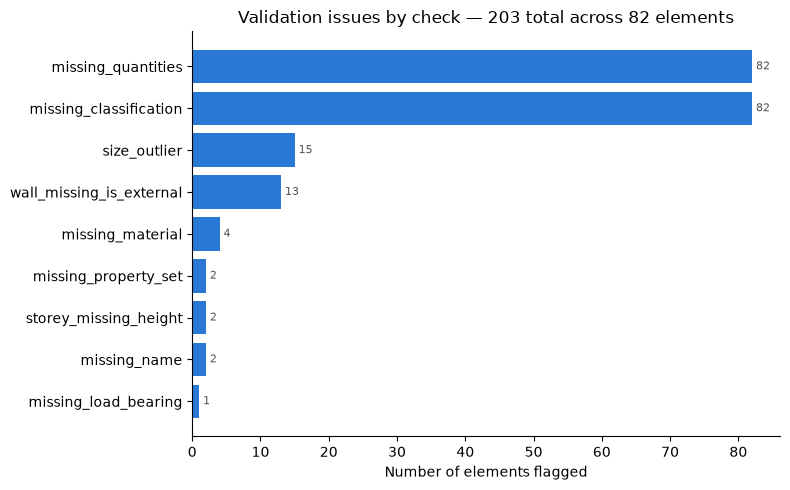

,check,count
0,missing_classification,82
1,missing_quantities,82
2,size_outlier,15
3,wall_missing_is_external,13
4,missing_material,4
5,missing_name,2
6,missing_property_set,2
7,storey_missing_height,2
8,missing_load_bearing,1


In [12]:
df_issues = pd.DataFrame(issues)
df_issues.to_csv("ifc_validation_issues.csv", index=False)

report = df_issues.groupby("check").size().reset_index(name="count").sort_values("count")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(report["check"], report["count"], color=SEQUENTIAL_BLUE)
for y, v in enumerate(report["count"]):
    ax.text(v, y, f" {v}", va="center", fontsize=8, color="#52514e")
ax.set_xlabel("Number of elements flagged")
ax.set_title(f"Validation issues by check — {len(df_issues)} total across {len(elements)} elements")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

report.sort_values("count", ascending=False).reset_index(drop=True)